In [6]:
import h5py
import numpy as np
import math
import gvar as gv
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma

# ---------------------------------------------------------
# 1. Jackknife Statistics Helper (Exact from User)
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    # Fallback for 0 or negative error
    if err <= 0:
        return f"{mean}"
        
    # Switch to scientific if very small/big
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        # Calculate exponent of the mean
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp
        
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))
        
        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"
        
    else:
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1))  # -1 gives us 2 sig figs instead of 1
        
        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"


def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        # Load the jackknifed parameter samples
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            fitted_params[key] = param_group[key][:]
            
        # Load the chi-square per dof array
        chi2_dof_list = f["chi2_dof"][:]
        
    return fitted_params, chi2_dof_list

# ---------------------------------------------------------
# 2. Extrapolation Routine using LSQFIT
# ---------------------------------------------------------
def fit_1_over_zeta_lsqfit(inv_zeta_vals, y_jk_samples):
    """
    Fits y = c0 + c1 * (1/zeta_hat) separately for every jackknife sample.
    inv_zeta_vals: 1D array of length N_PL
    y_jk_samples: 2D array of shape (N_PL, N_JK) containing the finite momentum ratio
    """
    N_PL, N_JK = y_jk_samples.shape

    # 1. Evaluate Jackknife Mean and Covariance
    mean_y = np.mean(y_jk_samples, axis=1)

    cov_y = np.cov(y_jk_samples, bias=True) * (N_JK - 1)
    '''
    cov_y = np.zeros((N_PL, N_PL))
    for i in range(N_PL):
        for j in range(N_PL):
            cov_y[i, j] = ((N_JK - 1) / N_JK) * np.sum(
                (y_jk_samples[i, :] - mean_y[i]) * (y_jk_samples[j, :] - mean_y[j])
            )
    '''

    # Create gvar for the central fit to get accurate chi2/dof
    try:
        y_gvar = gv.gvar(mean_y, cov_y)
    except Exception:
        # Fallback to diagonal errors if covariance matrix is numerically degenerate
        y_gvar = gv.gvar(mean_y, np.sqrt(np.diag(cov_y)))

    def fcn(x, p):
        # We enforce strictly non-negative c0 by exponentiating the fitted parameter
        c0 = np.exp(p['log_c0']) 
        return c0 + p['c2'] * x

    # Loose prior: using a gvar of 0(50) for log_c0 spans roughly exp(-50) to exp(+50), 
    # practically giving it a free range from zero to infinity without ever crossing below zero.
    prior = {'log_c0': gv.gvar(0, 50), 'c2': gv.gvar(0, 5000000)}

    # 2. Fit every individual jackknife sample
    c0_jk = []
    cov_y_eval = gv.evalcov(y_gvar)
    chi2_dof_list = []

    for k in range(N_JK):
        # We use the full ensemble covariance but shift the central values to the specific JK sample
        y_k_gvar = gv.gvar(y_jk_samples[:, k], cov_y_eval)
        fit_k = lsqfit.nonlinear_fit(data=(inv_zeta_vals, y_k_gvar), fcn=fcn, prior=prior)
        
        # Extract the exponentiated parameter back into our normal c0 array
        c0_jk.append(np.exp(fit_k.pmean['log_c0']))
        chi2_dof_list.append(fit_k.chi2 / fit_k.dof)

    # Return the list of extrapolated c0 values and chi2 for external processing
    return c0_jk, chi2_dof_list

# ---------------------------------------------------------
# 3. Main Sivers Extrapolation & Plotting
# ---------------------------------------------------------
def extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=100):
    
    # Range of x from 0 to 1
    x_vals = np.linspace(0, 1, num_points_x)
    
    # Exact provided mapping for PL to zeta_hat
    pl_to_zeta = {
        -4: 0.785756,
        -3: 0.539684,
        -2: 0.294367,
        -1: 0.090772
    }
    
    # Calculate 1/zeta_hat and sort to ensure ascending arrays
    inv_zeta_vals = np.array([1.0 / pl_to_zeta[pl] for pl in PL_list])
    sort_idx = np.argsort(inv_zeta_vals)
    inv_zeta_vals = inv_zeta_vals[sort_idx]
    sorted_PL_list = [PL_list[i] for i in sort_idx]
    N_PL = len(sorted_PL_list)
    
    # Discover N_JK from the first file
    init_filename = f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{sorted_PL_list[0]}.h5"
    init_params, _ = load_params_from_h5(init_filename)
    N_JK = len(init_params['a_re'])

    # Pre-allocate ratio arrays: shape (N_PL, num_points_x, N_JK)
    siv_finite_all = np.zeros((N_PL, num_points_x, N_JK))
    xsiv_finite_all = np.zeros((N_PL, num_points_x, N_JK))

    for i, pl in enumerate(sorted_PL_list):
        filename = f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{pl}.h5"
        fitted_params, _ = load_params_from_h5(filename)
        
        # Scaling parameters
        a_re, c_re, j_re, d_re = fitted_params['a_re'], fitted_params['c_re'] / (pl**2), fitted_params['j_re'], 1.0 + fitted_params['d_re'] * b2
        a_im, c_im, j_im, d_im = fitted_params['a_im'] / pl, fitted_params['c_im'] / (pl**2), fitted_params['j_im'], 1.0 + fitted_params['d_im'] * b2
        a_reA12B, c_reA12B, j_reA12B, d_reA12B = -fitted_params['a_reA12B'], fitted_params['c_reA12B'] / (pl**2), fitted_params['j_reA12B'], 1.0 + fitted_params['d_reA12B'] * b2

        lata = 0.11403
        mass_filepath = "/pscratch/sd/h/hari_8/TMD_fit/h5data/MassN_Jackknife.h5"
        with h5py.File(mass_filepath, "r") as f:
            # This loads the mass array of shape (N_JK,)
            MassN_jk = f[f"PL_{pl}"][:] 
        massterm = MassN_jk * (197.32698 * 0.001 / lata)
        for j, x in enumerate(x_vals):
            abs_x = max(np.abs(x), 1e-12)
            safe_x = x if x != 0 else 1e-12

            # ReA2B
            cd_R = c_re / d_re
            term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
            re_evals = term1_R * (abs_x**(-0.5 + j_re)) * kv(0.5 - j_re, abs_x / np.sqrt(cd_R))

            # ImA2B
            cd_I = c_im / d_im
            term1_I = (2**(1 - j_im) * a_im * cd_I**(0.25 * (-3 - 2*j_im)) * d_im**(-j_im)) / gamma(j_im)
            im_evals = term1_I * (safe_x * abs_x**(-1.5 + j_im)) * kv(1.5 - j_im, np.sqrt(d_im / c_im) * abs_x)

            # ReA12B
            cd_RA12B = c_reA12B / d_reA12B
            term1_RA12B = (2**(1 - j_reA12B) * a_reA12B * cd_RA12B**(-0.25 - j_reA12B/2) * d_reA12B**(-j_reA12B)) / gamma(j_reA12B)
            reA12B_evals = term1_RA12B * (abs_x**(-0.5 + j_reA12B)) * kv(0.5 - j_reA12B, abs_x / np.sqrt(cd_RA12B))

            # Calculate the Sivers Shift exact array for this specific PL
            # Note: massterm must be defined in the broader script scope.
            siv_evals = (-massterm * reA12B_evals) / (re_evals - im_evals)
            
            siv_finite_all[i, j, :] = siv_evals
            xsiv_finite_all[i, j, :] = safe_x * siv_evals

   
    print(f"{'x':<6} | {'Sivers shift (1/z=0 limit)':<25} | {'chi2/dof'}")
    print("-" * 55)

    siv_m, siv_e = np.zeros(num_points_x), np.zeros(num_points_x)
    xsiv_m, xsiv_e = np.zeros(num_points_x), np.zeros(num_points_x)

    for j, x in enumerate(tqdm(x_vals)):
        
        # Fit Sivers Ratio
        c0_jk_siv, chi2_siv = fit_1_over_zeta_lsqfit(inv_zeta_vals, siv_finite_all[:, j, :])
        # Use exact Jackknife function provided to get mean and error
        siv_m[j], siv_e[j] = Jackknife(c0_jk_siv)
        
        # Fit x*Sivers Ratio
        #c0_jk_xsiv, chi2_xsiv = fit_1_over_zeta_lsqfit(inv_zeta_vals, xsiv_finite_all[:, j, :])
        # Use exact Jackknife function provided to get mean and error
        xsiv_m[j], xsiv_e[j] = Jackknife(x*np.array(c0_jk_siv))

        #if j % 10 == 0 or j == len(x_vals)-1:
        print(f"{x:5.2f}  |  {fmt_err(siv_m[j], siv_e[j])}       |  {fmt_err(*Jackknife(chi2_siv))}")
        #print(f"{x:5.2f}  |  {fmt_err(siv_m,siv_e)}       |  {fmt_err(Jackknife(chi2_siv))}")

    # ---------------------------------------------------------
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Sivers Shift Plot
    axes[0].plot(x_vals, siv_m, color='olive', linewidth=2)
    axes[0].fill_between(x_vals, siv_m - siv_e, siv_m + siv_e, color='olive', alpha=0.3)
    axes[0].set_title(f'Sivers Shift $\\langle k_{{y}} \\rangle_{{TU}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d/\\hat{{\\zeta}}$]', fontsize=14)
    axes[0].set_xlabel('$x$', fontsize=12)
    axes[0].set_ylabel('$\\langle k_{y} \\rangle_{TU}$(GeV)', fontsize=12)
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # x * Sivers Shift Plot
    axes[1].plot(x_vals, xsiv_m, color='darkorange', linewidth=2)
    axes[1].fill_between(x_vals, xsiv_m - xsiv_e, xsiv_m + xsiv_e, color='darkorange', alpha=0.3)
    axes[1].set_title(f'$x *$ Sivers Shift ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d/\\hat{{\\zeta}}$]', fontsize=14)
    axes[1].set_xlabel('$x$', fontsize=12)
    axes[1].set_ylabel('$x\\langle k_{y} \\rangle_{TU}$(GeV)', fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    file_name = f"Extrapolated_Sivers_1_over_zetahat_P234_bmin{bminfit}_eta{etamin}{etamax}_b2{b2}.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()

x      | Sivers shift (1/z=0 limit) | chi2/dof
-------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]

 0.00  |  0.17(12)       |  1.8(15)
 0.02  |  0.168(61)       |  0.002(43)
 0.04  |  0.185(61)       |  0.01(14)
 0.06  |  0.190(59)       |  0.05(25)
 0.08  |  0.185(55)       |  0.11(38)
 0.10  |  0.173(49)       |  0.21(52)
 0.12  |  0.155(42)       |  0.34(67)
 0.14  |  0.135(35)       |  0.48(80)
 0.16  |  0.120(29)       |  0.54(85)
 0.18  |  0.110(26)       |  0.47(79)
 0.20  |  0.102(24)       |  0.33(66)
 0.22  |  0.091(22)       |  0.19(51)
 0.24  |  0.078(19)       |  0.10(37)
 0.27  |  0.062(16)       |  0.05(25)
 0.29  |  0.047(14)       |  0.02(14)
 0.31  |  0.032(12)       |  0.004(55)
 0.33  |  0.019(11)       |  0.003(23)
 0.35  |  0.006(10)       |  0.009(88)
 0.37  |  8(15)e-5       |  0.11(36)
 0.39  |  3.3(22)e-5       |  0.67(94)
 0.41  |  2.4(11)e-5       |  1.5(14)
 0.43  |  2.02(72)e-5       |  2.3(17)
 0.45  |  1.86(58)e-5       |  3.0(20)
 0.47  |  1.77(51)e-5       |  3.6(22)
 0.49  |  1.73(47)e-5       |  4.0(23)
 0.51  |  1.72(45)e-5       |  4.3(24)
 0.53

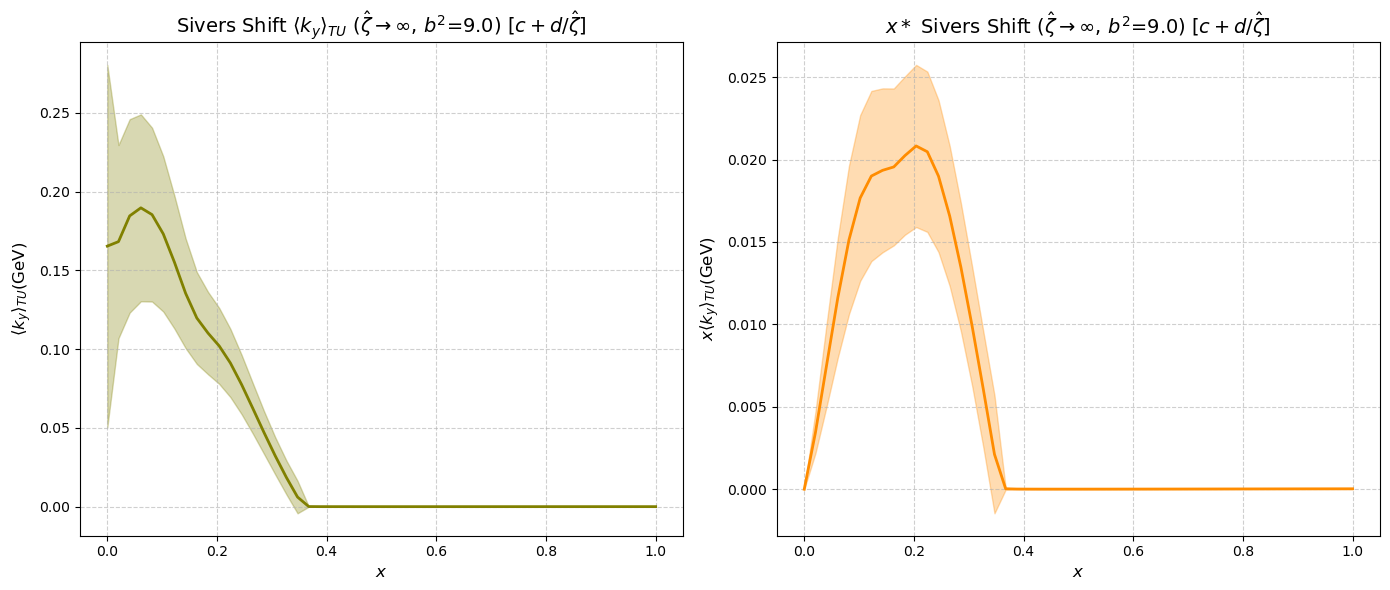

In [7]:
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-2, -3, -4]

    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=50)

x      | Sivers shift (1/z=0 limit) | chi2/dof
-------------------------------------------------------


  0%|          | 0/50 [00:00<?, ?it/s]

 0.00  |  0.220(83)       |  1.9(16)
 0.02  |  0.173(42)       |  0.003(55)
 0.04  |  0.183(42)       |  0.01(13)
 0.06  |  0.186(41)       |  0.04(24)
 0.08  |  0.184(38)       |  0.10(37)
 0.10  |  0.176(35)       |  0.21(52)
 0.12  |  0.163(30)       |  0.36(69)
 0.14  |  0.148(25)       |  0.54(85)
 0.16  |  0.135(21)       |  0.65(93)
 0.18  |  0.128(18)       |  0.60(89)
 0.20  |  0.121(17)       |  0.44(77)
 0.22  |  0.113(15)       |  0.29(62)
 0.24  |  0.103(13)       |  0.18(48)
 0.27  |  0.092(11)       |  0.10(37)
 0.29  |  0.0811(89)       |  0.06(28)
 0.31  |  0.0701(75)       |  0.03(20)
 0.33  |  0.0596(66)       |  0.01(13)
 0.35  |  0.0500(61)       |  0.005(68)
 0.37  |  0.0411(59)       |  0.002(19)
 0.39  |  0.0331(59)       |  0.002(31)
 0.41  |  0.0260(61)       |  0.006(71)
 0.43  |  0.0196(62)       |  0.01(11)
 0.45  |  0.0141(63)       |  0.02(14)
 0.47  |  0.0092(64)       |  0.02(17)
 0.49  |  0.0050(64)       |  0.03(20)
 0.51  |  0.0014(61)       |  0.04(

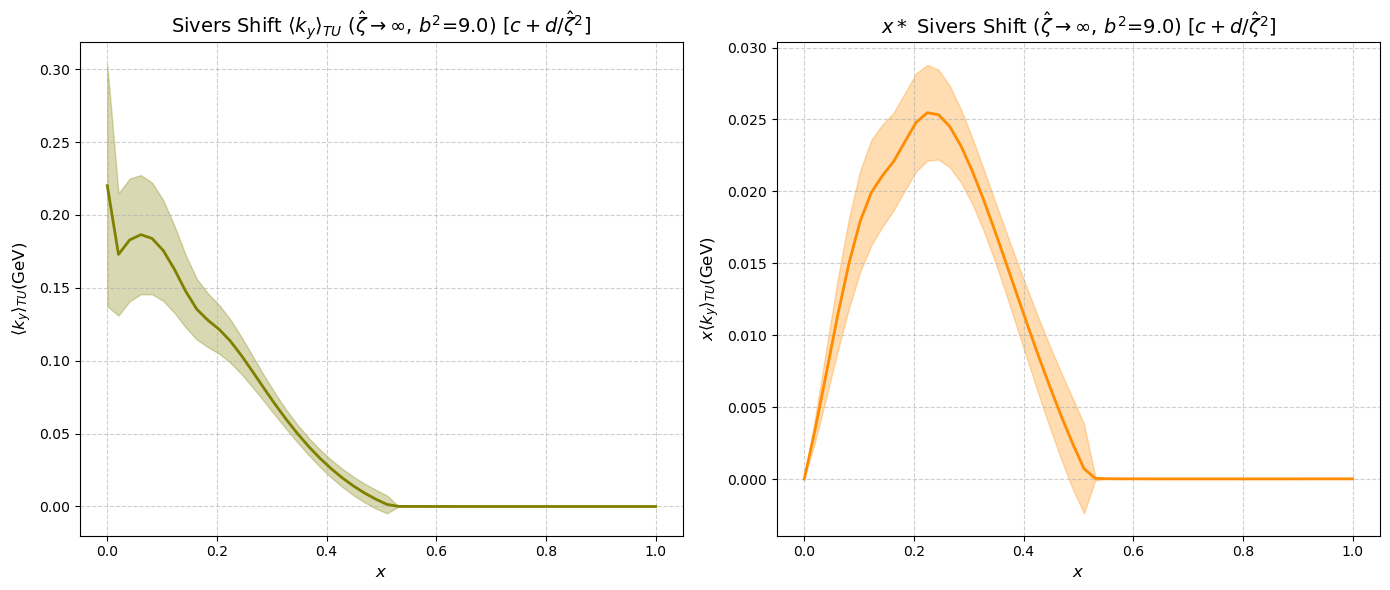

In [4]:
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [-2, -3, -4]

    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=50)

In [24]:
import h5py
import numpy as np
import math
import gvar as gv
import lsqfit
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.special import kv, gamma

# ---------------------------------------------------------
# 1. Jackknife Statistics Helper (Exact from User)
# ---------------------------------------------------------
def Jackknife(datalist): 
    N = len(datalist)
    theta_bar = np.mean(datalist)
    theta_nminus_theta_bar = []
    for i in range(N): 
        theta_n = datalist[i]
        theta_nminus_theta_bar.append(np.square(theta_n - theta_bar))
    sigma_sq = ((N-1)/N) * np.sum(theta_nminus_theta_bar)
    return theta_bar, np.sqrt(sigma_sq)

def fmt_err(mean, err):
    # Fallback for 0 or negative error
    if err <= 0:
        return f"{mean}"
        
    # Switch to scientific if very small/big
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        # Calculate exponent of the mean
        exp = int(math.floor(math.log10(abs(mean))))
        mean_scaled = mean / 10**exp
        err_scaled = err / 10**exp
        
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err_scaled))))
        ndec = max(0, -(place - 1))
        
        m_str = f"{mean_scaled:.{ndec}f}"
        err_int = int(round(err_scaled * 10**ndec))
        return f"{m_str}({err_int})e{exp}"
        
    else:
        # Find precision needed for exactly 2 significant digits of the error
        place = int(math.floor(math.log10(abs(err))))
        ndec = max(0, -(place - 1))  # -1 gives us 2 sig figs instead of 1
        
        m_str = f"{mean:.{ndec}f}"
        err_int = int(round(err * 10**ndec))
        return f"{m_str}({err_int})"


def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        # Load the jackknifed parameter samples
        param_group = f["jackknife_samples"]
        for key in param_group.keys():
            fitted_params[key] = param_group[key][:]
            
        # Load the chi-square per dof array
        chi2_dof_list = f["chi2_dof"][:]
        
    return fitted_params, chi2_dof_list

# ---------------------------------------------------------
# 2. Extrapolation Routine using LSQFIT
# ---------------------------------------------------------
def fit_1_over_zeta_lsqfit(inv_zeta_vals, y_jk_samples):
    """
    Fits y = c0 + c1 * (1/zeta_hat) separately for every jackknife sample.
    inv_zeta_vals: 1D array of length N_PL
    y_jk_samples: 2D array of shape (N_PL, N_JK) containing the finite momentum ratio
    """
    N_PL, N_JK = y_jk_samples.shape

    # 1. Evaluate Jackknife Mean and Covariance
    mean_y = np.mean(y_jk_samples, axis=1)

    cov_y = np.cov(y_jk_samples, bias=True) * (N_JK - 1)
    '''
    cov_y = np.zeros((N_PL, N_PL))
    for i in range(N_PL):
        for j in range(N_PL):
            cov_y[i, j] = ((N_JK - 1) / N_JK) * np.sum(
                (y_jk_samples[i, :] - mean_y[i]) * (y_jk_samples[j, :] - mean_y[j])
            )
    '''

    # Create gvar for the central fit to get accurate chi2/dof
    try:
        y_gvar = gv.gvar(mean_y, cov_y)
    except Exception:
        # Fallback to diagonal errors if covariance matrix is numerically degenerate
        y_gvar = gv.gvar(mean_y, np.sqrt(np.diag(cov_y)))

    def fcn(x, p):
        # Enforce non-negativity by exponentiating the fitted log parameter
        c0 = np.exp(p['log_c0'])
        return c0 + p['c2'] * x**2

    # Loose prior. A gvar of 0(50) for a log parameter allows the exponentiated 
    # value to range from virtually 0 to +infinity.
    prior = {'log_c0': gv.gvar(0, 50), 'c2': gv.gvar(0, 5000000)}


    # 2. Fit every individual jackknife sample
    c0_jk = []
    cov_y_eval = gv.evalcov(y_gvar)
    chi2_dof_list = []

    for k in range(N_JK):
        # We use the full ensemble covariance but shift the central values to the specific JK sample
        y_k_gvar = gv.gvar(y_jk_samples[:, k], cov_y_eval)
        fit_k = lsqfit.nonlinear_fit(data=(inv_zeta_vals, y_k_gvar), fcn=fcn, prior=prior)
        
        # Extract and exponentiate to get the true c0
        c0_jk.append(np.exp(fit_k.pmean['log_c0']))
        chi2_dof_list.append(fit_k.chi2 / fit_k.dof)

    # Return the list of extrapolated c0 values and chi2 for external processing
    return c0_jk, chi2_dof_list

# ---------------------------------------------------------
# 3. Main Sivers Extrapolation & Plotting
# ---------------------------------------------------------
def extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=100):
    
    # Range of x from 0 to 1
    x_vals = np.linspace(0, 1, num_points_x)
    
    lata = 0.11403
    
    # Exact provided mapping for PL to zeta_hat
    pl_to_zeta = {
        -4: 0.785756,
        -3: 0.539684,
        -2: 0.294367,
        -1: 0.090772
    }
    
    # Calculate 1/zeta_hat and sort to ensure ascending arrays
    inv_zeta_vals = np.array([1.0 / pl_to_zeta[pl] for pl in PL_list])
    sort_idx = np.argsort(inv_zeta_vals)
    inv_zeta_vals = inv_zeta_vals[sort_idx]
    sorted_PL_list = [PL_list[i] for i in sort_idx]
    N_PL = len(sorted_PL_list)
    
    # Discover N_JK from the first file
    init_filename = f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{sorted_PL_list[0]}.h5"
    init_params, _ = load_params_from_h5(init_filename)
    N_JK = len(init_params['a_re'])

    # Pre-allocate ratio arrays: shape (N_PL, num_points_x, N_JK)
    re_evals_finite_all = np.zeros((N_PL, num_points_x, N_JK))
    im_evals_finite_all = np.zeros((N_PL, num_points_x, N_JK))
    reA12B_evals_finite_all = np.zeros((N_PL, num_points_x, N_JK))

    for i, pl in enumerate(sorted_PL_list):
        filename = f"/pscratch/sd/h/hari_8/TMD_fit/h5data/FitParams_SimulFit_f_A2BRe_cetasq_A2BIm_A12BRe_bmin{bminfit}_eta{etamin}{etamax}_PL{pl}.h5"
        fitted_params, _ = load_params_from_h5(filename)
        
        # Load MassN Jackknife data for the current PL
        mass_filepath = "/pscratch/sd/h/hari_8/TMD_fit/h5data/MassN_Jackknife.h5"
        with h5py.File(mass_filepath, "r") as f:
            # This loads the mass array of shape (N_JK,)
            MassN_jk = f[f"PL_{pl}"][:] 
        massterm = MassN_jk * (197.32698 * 0.001 / lata)
        
        # Scaling parameters
        a_re, c_re, j_re, d_re = fitted_params['a_re'], fitted_params['c_re'] / (pl**2), fitted_params['j_re'], 1.0 + fitted_params['d_re'] * b2
        a_im, c_im, j_im, d_im = fitted_params['a_im'] / pl, fitted_params['c_im'] / (pl**2), fitted_params['j_im'], 1.0 + fitted_params['d_im'] * b2
        a_reA12B, c_reA12B, j_reA12B, d_reA12B = -fitted_params['a_reA12B'], fitted_params['c_reA12B'] / (pl**2), fitted_params['j_reA12B'], 1.0 + fitted_params['d_reA12B'] * b2

        for j, x in enumerate(x_vals):
            abs_x = max(np.abs(x), 1e-12)
            safe_x = x if x != 0 else 1e-12

            # ReA2B
            cd_R = c_re / d_re
            term1_R = (2**(1 - j_re) * a_re * cd_R**(-0.25 - j_re/2) * d_re**(-j_re)) / gamma(j_re)
            re_evals = term1_R * (abs_x**(-0.5 + j_re)) * kv(0.5 - j_re, abs_x / np.sqrt(cd_R))

            # ImA2B
            cd_I = c_im / d_im
            term1_I = (2**(1 - j_im) * a_im * cd_I**(0.25 * (-3 - 2*j_im)) * d_im**(-j_im)) / gamma(j_im)
            im_evals = term1_I * (safe_x * abs_x**(-1.5 + j_im)) * kv(1.5 - j_im, np.sqrt(d_im / c_im) * abs_x)

            # ReA12B
            cd_RA12B = c_reA12B / d_reA12B
            term1_RA12B = (2**(1 - j_reA12B) * a_reA12B * cd_RA12B**(-0.25 - j_reA12B/2) * d_reA12B**(-j_reA12B)) / gamma(j_reA12B)
            reA12B_evals = term1_RA12B * (abs_x**(-0.5 + j_reA12B)) * kv(0.5 - j_reA12B, abs_x / np.sqrt(cd_RA12B))

            # Calculate the Sivers Shift exact array for this specific PL
            #siv_evals = (-massterm * reA12B_evals) / (re_evals - im_evals)

            re_evals_finite_all[i, j, :] = re_evals
            im_evals_finite_all[i, j, :] = -im_evals
            reA12B_evals_finite_all[i, j, :] = -reA12B_evals
            #siv_finite_all[i, j, :] = siv_evals
            #xsiv_finite_all[i, j, :] = safe_x * siv_evals

   
    print(f"{'x':<6} | {'Sivers shift (1/z=0 limit)':<25} | {'ReA2B: chi2/dof'} | {'ImA2B: chi2/dof'} | {'ReA12B: chi2/dof'}")
    print("-" * 55)

    reA2B_m, reA2B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    imA2B_m, imA2B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    A2B_m, A2B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    reA12B_m, reA12B_e = np.zeros(num_points_x), np.zeros(num_points_x)
    
    siv_m, siv_e = np.zeros(num_points_x), np.zeros(num_points_x)
    xsiv_m, xsiv_e = np.zeros(num_points_x), np.zeros(num_points_x)

    for j, x in enumerate(tqdm(x_vals)):

        
        c0_jk_A2Bre, chi2_A2Bre = fit_1_over_zeta_lsqfit(inv_zeta_vals, re_evals_finite_all[:, j, :])
        reA2B_m[j], reA2B_e[j] = Jackknife(c0_jk_A2Bre)

        c0_jk_A2Bim, chi2_A2Bim = fit_1_over_zeta_lsqfit(inv_zeta_vals, im_evals_finite_all[:, j, :])
        imA2B_m[j], imA2B_e[j] = Jackknife(-(np.array(c0_jk_A2Bim)))

        c0_jk_A12Bre, chi2_A12Bre = fit_1_over_zeta_lsqfit(inv_zeta_vals, reA12B_evals_finite_all[:, j, :])
        reA12B_m[j], reA12B_e[j] = Jackknife(2*(np.array(c0_jk_A12Bre)))

        A2B_m[j], A2B_e[j] = Jackknife(2*(np.array(c0_jk_A2Bre) + np.array(c0_jk_A2Bim)))
        
        SivShift_j = (massterm * np.array(c0_jk_A12Bre)) / (np.array(c0_jk_A2Bre) + np.array(c0_jk_A2Bim))
        siv_m[j], siv_e[j] = Jackknife(SivShift_j)
        
        xsiv_m[j], xsiv_e[j] = Jackknife(x*(SivShift_j))

        #if j % 10 == 0 or j == len(x_vals)-1:
        print(f"{x:5.2f}  |  {fmt_err(siv_m[j], siv_e[j])}       |  {fmt_err(*Jackknife(np.array(chi2_A2Bre)))}       |  {fmt_err(*Jackknife(np.array(chi2_A2Bim)))}       |  {fmt_err(*Jackknife(np.array(chi2_A12Bre)))}")
        #print(f"{x:5.2f}  |  {fmt_err(siv_m,siv_e)}       |  {fmt_err(Jackknife(chi2_siv))}")

    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(14, 8))

    # Real Plot
    ax1.plot(x_vals, reA2B_m, color='blue', label='ReA2B Mean')
    ax1.fill_between(x_vals, reA2B_m - reA2B_e, reA2B_m + reA2B_e, color='blue', alpha=0.3)
    ax1.set_title(f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d/\\hat{{\\zeta}}^2$]')
    ax1.set_xlabel('$x$')
    ax1.set_ylabel('$\\tilde{{A}}_{{2B}}^{{Re}}$')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Imaginary Plot
    ax2.plot(x_vals, imA2B_m, color='red', label='ImA2B Mean')
    ax2.fill_between(x_vals, imA2B_m - reA12B_e, imA2B_m + reA12B_e, color='red', alpha=0.3)
    ax2.set_title(f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d/\\hat{{\\zeta}}^2$]')
    ax2.set_xlabel('$x$')
    ax2.set_ylabel('$i\\tilde{{A}}_{{2B}}^{{Im}}$')
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Full f1 Plot
    ax3.plot(x_vals, A2B_m, color='purple', label='A2B Mean')
    ax3.fill_between(x_vals, A2B_m - A2B_e, A2B_m + A2B_e, color='purple', alpha=0.3)
    ax3.set_title(f'$\\tilde{{f}}_{{1}}^{{(0)}}=2\\tilde{{A}}_{{2B}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d/\\hat{{\\zeta}}^2$]')
    ax3.set_xlabel('$x$')
    ax3.set_ylabel('$\\tilde{{f}}_{{1}}^{{(0)}}$')
    ax3.grid(True, linestyle='--', alpha=0.6)

    # A12B Plot
    ax4.plot(x_vals, reA12B_m, color='green')
    ax4.fill_between(x_vals, reA12B_m - reA12B_e, reA12B_m + reA12B_e, color='green', alpha=0.3)
    ax4.set_title(f'$\\tilde{{f}}_{{1}}^{{\\perp(1)}}=-2\\tilde{{A}}_{{12B}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d/\\hat{{\\zeta}}^2$]')
    ax4.set_xlabel('$x$')
    ax4.set_ylabel('$\\tilde{{f}}_{{1}}^{{\\perp(1)}}$')
    ax4.grid(True, linestyle='--', alpha=0.6)

    # Sivers Shift Plot
    ax5.plot(x_vals, siv_m, color='olive', linewidth=2)
    ax5.fill_between(x_vals, siv_m - siv_e, siv_m + siv_e, color='olive', alpha=0.3)
    ax5.set_title(f'Sivers Shift $\\langle k_{{y}} \\rangle_{{TU}}$ ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d/\\hat{{\\zeta}}^2$]', fontsize=14)
    ax5.set_xlabel('$x$', fontsize=12)
    ax5.set_ylabel('$\\langle k_{y} \\rangle_{TU}$(GeV)', fontsize=12)
    ax5.grid(True, linestyle='--', alpha=0.6)

    # x * Sivers Shift Plot
    ax6.plot(x_vals, xsiv_m, color='darkorange', linewidth=2)
    ax6.fill_between(x_vals, xsiv_m - xsiv_e, xsiv_m + xsiv_e, color='darkorange', alpha=0.3)
    ax6.set_title(f'$x *$ Sivers Shift ($\\hat{{\\zeta}} \\to \\infty$, $b^2$={b2}) [$c+d/\\hat{{\\zeta}}^2$]', fontsize=14)
    ax6.set_xlabel('$x$', fontsize=12)
    ax6.set_ylabel('$x\\langle k_{y} \\rangle_{TU}$(GeV)', fontsize=12)
    ax6.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    file_name = f"Extrapolated_AmpLevel_P123_Sivers_1_over_zetahatsq_bmin{bminfit}_eta{etamin}{etamax}_b2{b2}.pdf"
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()

x      | Sivers shift (1/z=0 limit) | ReA2B: chi2/dof | ImA2B: chi2/dof | ReA12B: chi2/dof
-------------------------------------------------------


  0%|          | 0/20 [00:00<?, ?it/s]

 0.00  |  0.73(46)       |  0.61(90)       |  0.68(95)       |  0.16(46)
 0.05  |  0.29(11)       |  0.8(10)       |  2.0(16)       |  0.09(34)
 0.11  |  0.27(11)       |  1.5(14)       |  3.1(20)       |  0.01(12)
 0.16  |  0.118(44)       |  1.9(16)       |  3.5(22)       |  0.01(11)
 0.21  |  0.039(36)       |  0.19(51)       |  5.3(26)       |  0.06(28)
 0.26  |  3.5(14)e-5       |  2(153)e-4       |  13.7(43)       |  2.5(18)
 0.32  |  7.7(21)e-6       |  0.06(29)       |  23.6(56)       |  24.0(57)
 0.37  |  3.50(93)e-6       |  0.19(50)       |  36.1(69)       |  65.4(93)
 0.42  |  2.09(65)e-6       |  0.36(70)       |  51.5(83)       |  110(12)
 0.47  |  1.57(63)e-6       |  0.61(90)       |  68.4(95)       |  144(14)
 0.53  |  1.52(84)e-6       |  0.9(11)       |  86(11)       |  152(14)
 0.58  |  2.1(18)e-6       |  1.3(13)       |  103(12)       |  138(14)
 0.63  |  5(10)e-6       |  1.6(15)       |  120(13)       |  113(12)
 0.68  |  2.2(83)e-4       |  1.7(15)       |  135

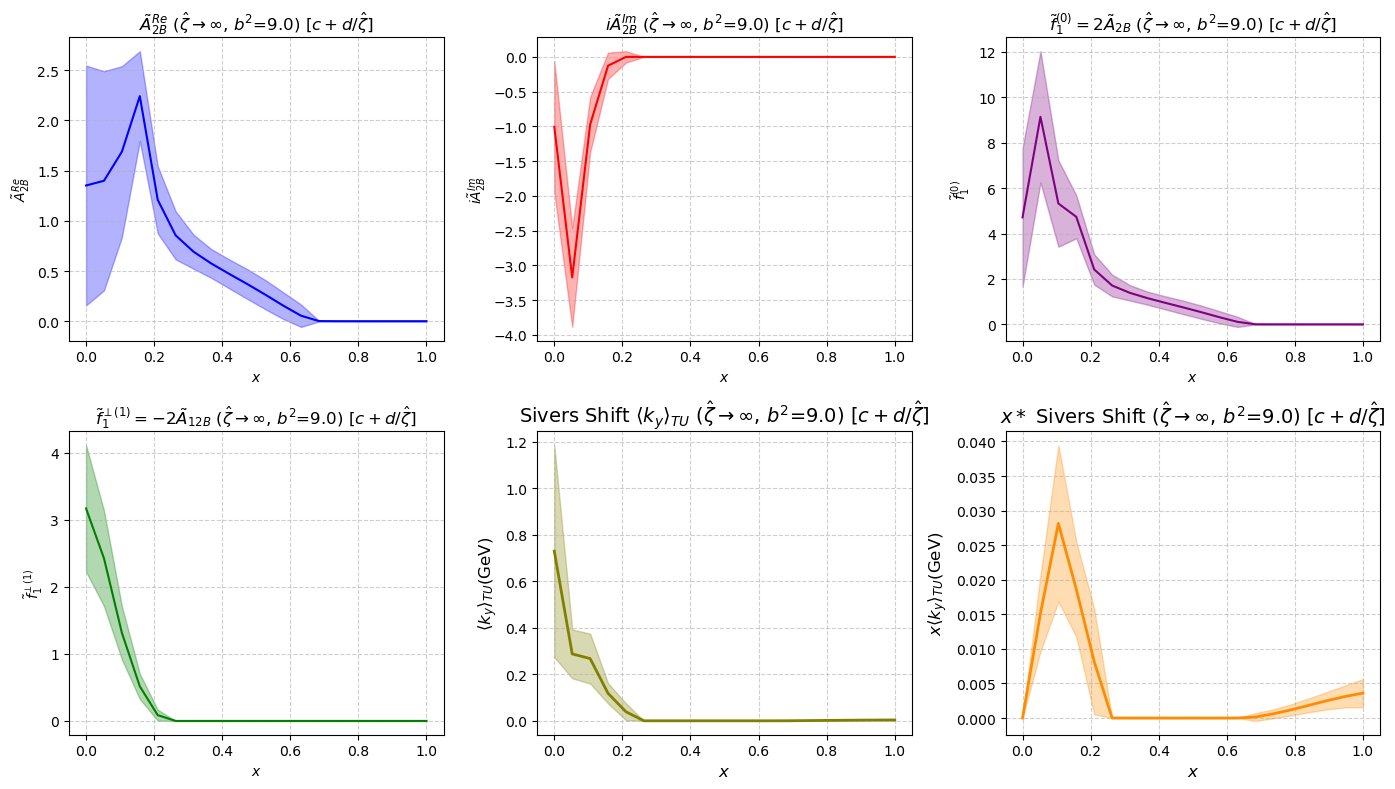

In [23]:
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [ -2, -3, -4]

    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=20)

x      | Sivers shift (1/z=0 limit) | ReA2B: chi2/dof | ImA2B: chi2/dof | ReA12B: chi2/dof
-------------------------------------------------------


  0%|          | 0/20 [00:00<?, ?it/s]

 0.00  |  0.54(18)       |  0.54(85)       |  0.72(98)       |  0.18(49)
 0.05  |  0.235(54)       |  0.69(96)       |  2.0(16)       |  0.09(34)
 0.11  |  0.220(48)       |  1.3(13)       |  3.9(23)       |  4(212)e-4
 0.16  |  0.143(25)       |  1.7(15)       |  5.7(28)       |  0.13(41)
 0.21  |  0.108(19)       |  0.10(37)       |  6.7(30)       |  0.65(93)
 0.26  |  0.061(10)       |  0.01(12)       |  6.1(29)       |  1.8(16)
 0.32  |  0.0266(50)       |  0.11(38)       |  4.3(24)       |  4.0(23)
 0.37  |  0.0054(30)       |  0.25(58)       |  2.0(16)       |  5.7(28)
 0.42  |  3.38(96)e-6       |  0.45(77)       |  2.0(16)       |  6.3(29)
 0.47  |  1.45(31)e-6       |  0.72(98)       |  7.9(32)       |  18.8(50)
 0.53  |  9.0(22)e-7       |  1.1(12)       |  18.4(50)       |  36.6(70)
 0.58  |  7.1(23)e-7       |  1.5(14)       |  32.0(65)       |  54.5(85)
 0.63  |  7.3(33)e-7       |  1.9(16)       |  47.2(79)       |  65.5(93)
 0.68  |  1.10(82)e-6       |  2.1(17)       | 

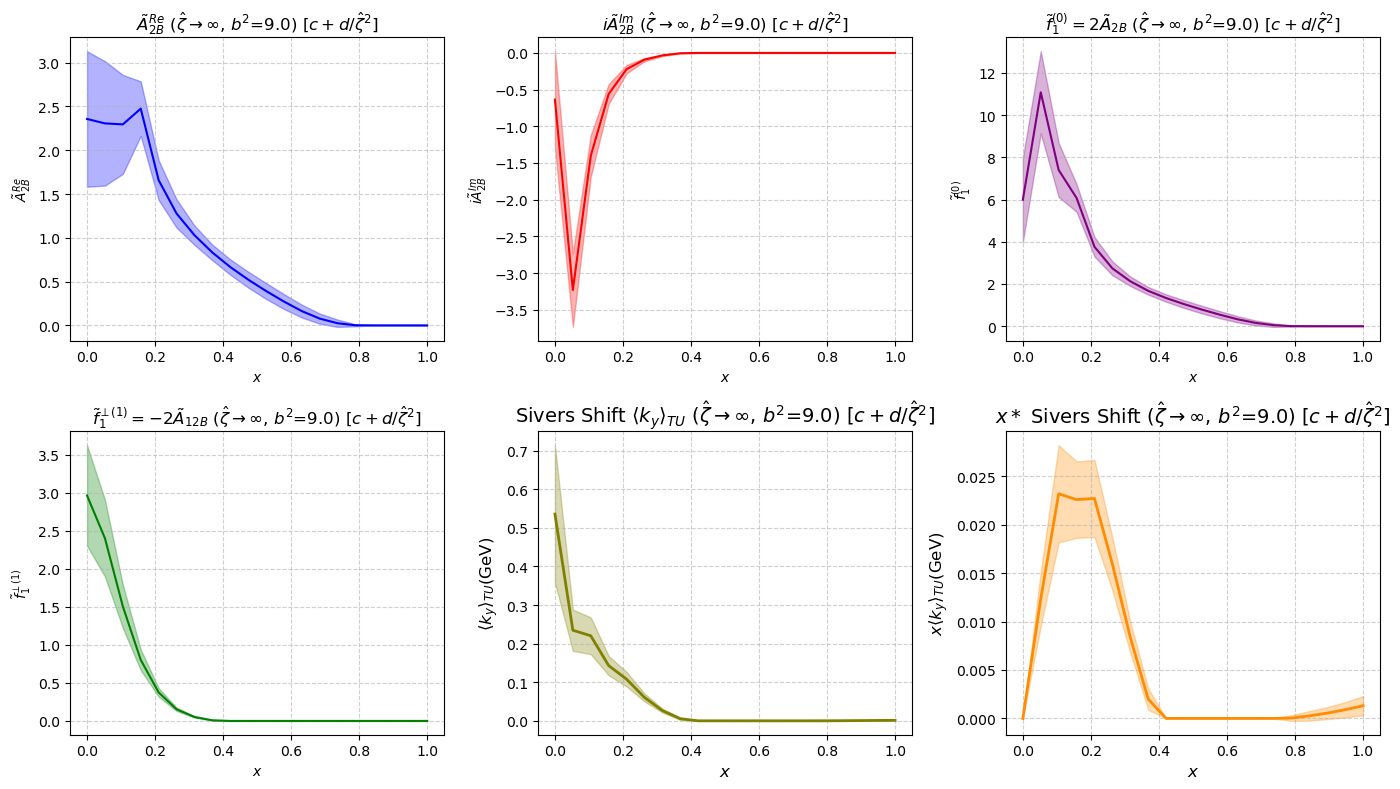

In [25]:
# ---------------------------------------------------------
if __name__ == "__main__":
    bminfit = 3
    etamin = 6
    etamax = 10
    PL_list = [ -2, -3, -4]

    extrapolate_and_plot_sivers(PL_list, bminfit, etamin, etamax, b2=9.0, num_points_x=20)